In [4]:
import pandas as pd

data = {
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'math': [85, 72, 90, 65, 78, 92, 70, 88, 75, 60],
    'science': [78, 80, 85, 70, 92, 88, 75, 82, 68, 90],
    'english': [90, 68, 75, 88, 80, 72, 85, 70, 92, 78],
    'history': [70, 75, 82, 90, 65, 88, 78, 92, 72, 85],
    'pe': [95, 88, 90, 82, 75, 92, 80, 85, 78, 90],
    'passed': [1, 0, 1, 0, 1, 1, 0, 1, 0, 1]
}
df_dummy = pd.DataFrame(data)
df_dummy.to_csv('students.csv', index=False)

df = pd.read_csv("students.csv")

# 1. First 5 rows
print("First 5 Rows:")
print(df.head())

# 2. Shape and data types
print("\nShape of dataset:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

# 3. Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# 4. Count of passed vs failed
print("\nPass/Fail Count:")
print(df["passed"].value_counts())

# 5. Average scores for pass vs fail
subject_cols = ["math", "science", "english", "history", "pe"]

pass_avg = df[df["passed"] == 1][subject_cols].mean()
fail_avg = df[df["passed"] == 0][subject_cols].mean()

print("\nAverage Scores (Passed Students):")
print(pass_avg)

print("\nAverage Scores (Failed Students):")
print(fail_avg)

# 6. Student with highest overall average
df["average"] = df[subject_cols].mean(axis=1)
top_student = df.loc[df["average"].idxmax()]

print("\nTop Student:")
print(f"{top_student['name']} with average {top_student['average']:.2f}")



First 5 Rows:
      name  math  science  english  history  pe  passed
0    Alice    85       78       90       70  95       1
1      Bob    72       80       68       75  88       0
2  Charlie    90       85       75       82  90       1
3    David    65       70       88       90  82       0
4      Eve    78       92       80       65  75       1

Shape of dataset:
(10, 7)

Data Types:
name         str
math       int64
science    int64
english    int64
history    int64
pe         int64
passed     int64
dtype: object

Summary Statistics:
            math    science    english    history         pe     passed
count  10.000000  10.000000  10.000000  10.000000  10.000000  10.000000
mean   77.500000  80.800000  79.800000  79.700000  85.500000   0.600000
std    10.997474   8.189424   8.625543   9.153627   6.570134   0.516398
min    60.000000  68.000000  68.000000  65.000000  75.000000   0.000000
25%    70.500000  75.750000  72.750000  72.750000  80.500000   0.000000
50%    76.500000  81.000

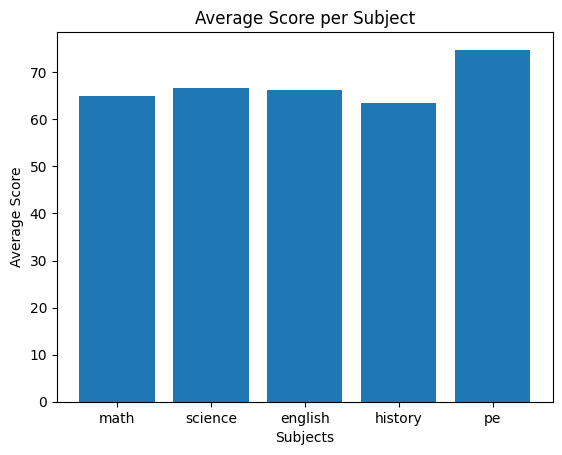

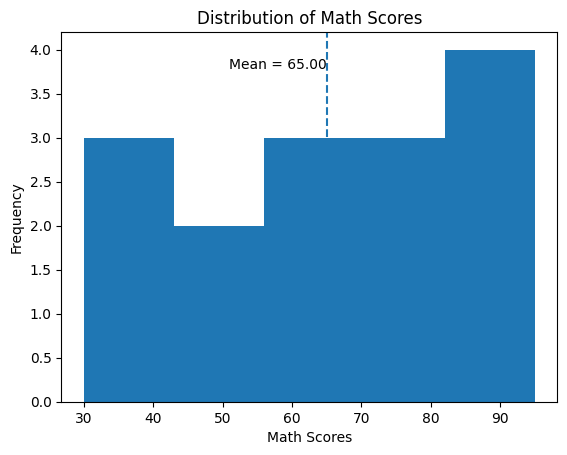

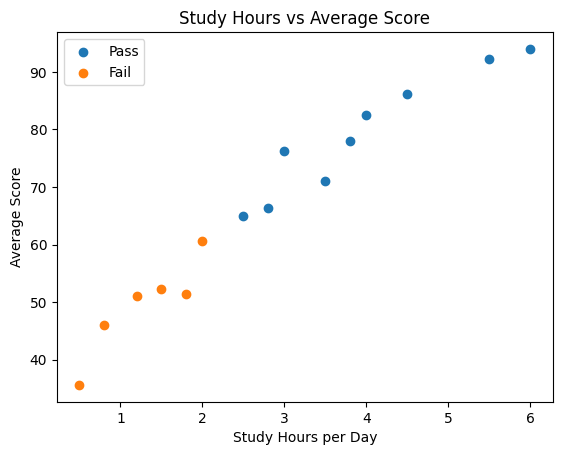

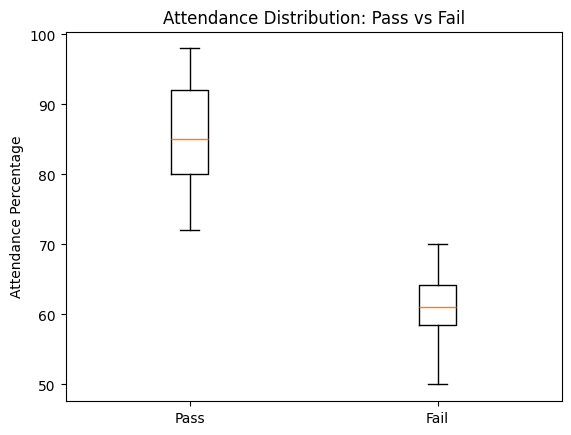

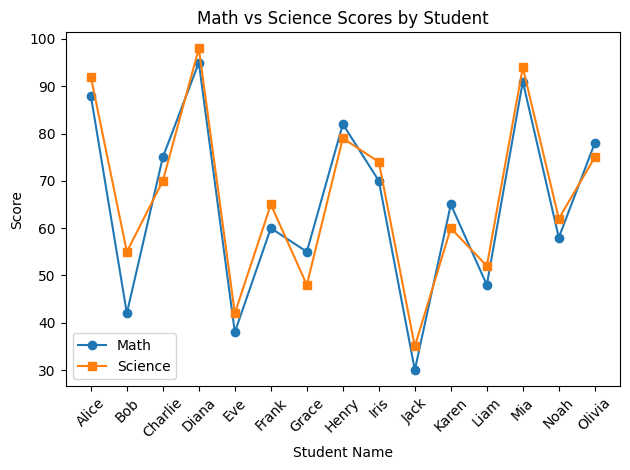

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import io

data_csv = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

df = pd.read_csv(io.StringIO(data_csv))

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()


plt.figure()
plt.hist(df['math'], bins=5)
mean_math = df['math'].mean()

plt.axvline(mean_math, linestyle='dashed')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Scores")
plt.ylabel("Frequency")
plt.text(mean_math, plt.ylim()[1] * 0.9, f"Mean = {mean_math:.2f}", ha='right') # Adjusted text position
plt.savefig("plot2_hist.png")
plt.show()


pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure()
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()


pass_attendance = pass_df['attendance_pct'].tolist()
fail_attendance = fail_df['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])

plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance Percentage")
plt.savefig("plot4_box.png")
plt.show()


plt.figure()
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()


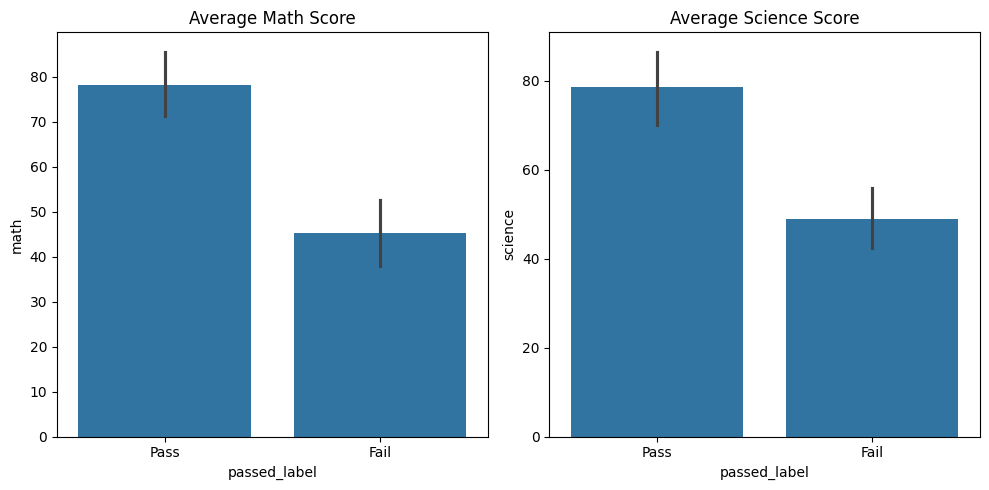

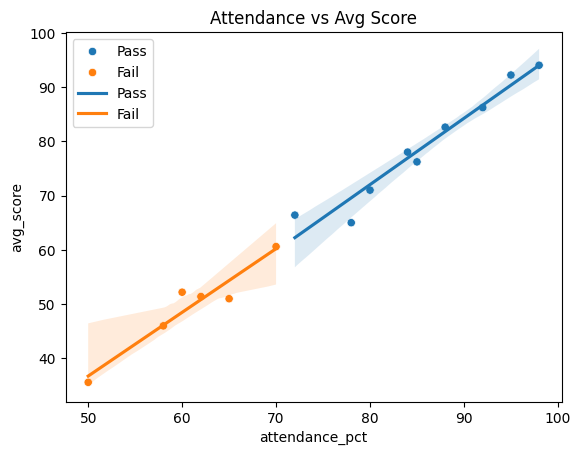

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io

data_csv = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

df = pd.read_csv(io.StringIO(data_csv))

df['avg_score'] = df[['math','science','english','history','pe']].mean(axis=1)
df['passed_label'] = df['passed'].map({1: 'Pass', 0: 'Fail'})

plt.figure(figsize=(10,5))

ax1 = plt.subplot(1,2,1)
sns.barplot(data=df, x='passed_label', y='math', ax=ax1)
ax1.set_title("Average Math Score")

ax2 = plt.subplot(1,2,2)
sns.barplot(data=df, x='passed_label', y='science', ax=ax2)
ax2.set_title("Average Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_barplots.png")
plt.show()

plt.figure()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed_label')

sns.regplot(data=df[df['passed']==1],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Pass')

sns.regplot(data=df[df['passed']==0],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Fail')

plt.title("Attendance vs Avg Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

Training Accuracy: 1.0
Test Accuracy: 1.0
Jack - Actual: 0, Predicted: 0 ✅
Liam - Actual: 0, Predicted: 0 ✅
Alice - Actual: 1, Predicted: 1 ✅
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


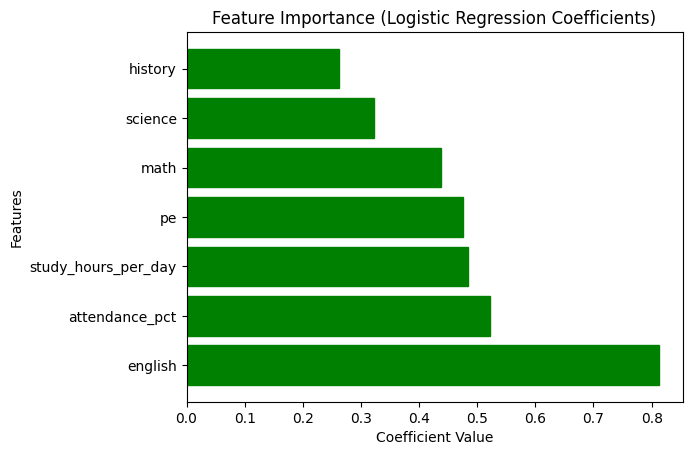


New Student Prediction:
Prediction: Pass
Probability [Fail, Pass]: [0.09203526 0.90796474]


c:\Users\91821\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import io

data_csv = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

df = pd.read_csv(io.StringIO(data_csv))

# Step 1 — Prepare Data
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2 — Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)

# Step 3 — Evaluate Model
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

names = df.loc[X_test.index, 'name']
for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅" if actual == pred else "❌"
    print(f"{name} - Actual: {actual}, Predicted: {pred} {result}")

# Step 4 — Feature Importance
coefficients = model.coef_[0]
feature_importance = sorted(
    zip(feature_cols, coefficients),
    key=lambda x: abs(x[1]),
    reverse=True
)

for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")

features = [f[0] for f in feature_importance]
coefs = [f[1] for f in feature_importance]

colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure()
bars = plt.barh(features, coefs)
for i, bar in enumerate(bars):
    bar.set_color(colors[i])

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.savefig("plot8_feature_importance.png")
plt.show()

# Step 5 — New Student Prediction
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

label = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:")
print("Prediction:", label)
print("Probability [Fail, Pass]:", probability)